# KLASIFIKASI KUALITAS PRODUK TIN STABILIZER MT-620 MENGGUNAKAN XGBOOST

## Alur Penelitian:
1. **Import Libraries & Load Data** — `Data_Chemical_Imputed.xlsx`
2. **Eksplorasi Data** — memahami struktur dan distribusi data
3. **Pembersihan Data** — konversi tipe & penanganan nilai tidak valid
4. **Encoding Fitur** — `APE`: *Clear* → 1, lainnya → 0
5. **KNN Imputation** — mengisi nilai kosong yang tersisa
6. **Labeling Per-Batch** — jika semua baris dalam satu batch *Passed* → Layak (1), ada yang *Not Passed* → Tidak Layak (0)
7. **Split Data** — 80% Training, 20% Validasi
8. **K-Fold Cross Validation** — 5-Fold Stratified
9. **Training Model XGBoost**
10. **Prediksi & Metrik Evaluasi**
11. **Confusion Matrix**
12. **Feature Importance & Ringkasan Akhir**

---

## 1. IMPORT LIBRARIES & LOAD DATA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')

print("Libraries berhasil dimuat!")

Libraries berhasil dimuat!


In [2]:
file_path = 'Data_Chemical_MT620_Only_Final.xlsx'
df_raw = pd.read_excel(file_path)

print(f"File    : {file_path}")
print(f"Baris   : {len(df_raw)}")
print(f"Kolom   : {len(df_raw.columns)}")
print(f"\nDaftar Kolom:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {col}")

File    : Data_Chemical_Imputed.xlsx
Baris   : 1499
Kolom   : 24

Daftar Kolom:
   1. ID
   2. Nama Chemical
   3. Nama
   4. Tanggal
   5. Jam Masuk
   6. Batch
   7. Deskripsi
   8. Status
   9. Transmission
  10. APE
  11. Tinx
  12. RI
  13. SG
  14. Acid
  15. Sulfur
  16. Water
  17. Mono
  18. Yellow
  19. EH
  20. Visco
  21. PT
  22. Created At
  23. Updated At
  24. Orang


## 2. EKSPLORASI DATA

In [3]:
print("5 Baris Pertama:")
df_raw.head()

5 Baris Pertama:


,ID,Nama Chemical,Nama,Tanggal,Jam Masuk,Batch,Deskripsi,Status,Transmission,APE,...,Sulfur,Water,Mono,Yellow,EH,Visco,PT,Created At,Updated At,Orang
0,11,Tinstab,MT-620,2025-05-07,2025-05-15 20:02:21,TG2024L28,ANALISIS ALL PARAMETER,Approve,99.275,Clear,...,12.081,3.48,22.384,7.84,0.00010,47.20,10.0,2025-05-07T08:34:05.000000Z,2025-05-15T13:02:21.000000Z,Nikmatullah
1,12,Tinstab,MT-620,2025-05-07,2025-05-15 20:02:43,TG2025A07,ANALISIS ALL PARAMETER,Approve,99.229,Clear,...,11.926,3.48,22.034,7.90,0.00050,45.07,10.0,2025-05-07T08:34:30.000000Z,2025-05-15T13:02:43.000000Z,Nikmatullah
2,13,Tinstab,MT-620,2025-05-07,2025-05-15 20:02:44,TG2025B07-1,ANALISIS ALL PARAMETER,Approve,99.286,Clear,...,11.849,3.48,21.766,7.79,0.00010,49.40,10.0,2025-05-07T08:34:50.000000Z,2025-05-15T13:02:44.000000Z,Nikmatullah
3,38,Tinstab,MT-620,2025-05-09,2025-05-20 00:44:11,TG02025E05,Awal tengah akhir,Approve,99.216,Clear,...,12.099,3.49,21.552,7.85,0.00014,49.60,10.0,2025-05-09T09:46:10.000000Z,2025-05-19T17:44:11.000000Z,Anto S
4,39,Tinstab,MT-620,2025-05-09,2025-05-19 23:56:22,TG02025E06,Awal tengah akhir,Approve,99.308,Clear,...,12.176,3.49,22.250,7.82,0.00012,47.20,10.0,2025-05-09T09:46:53.000000Z,2025-05-19T16:56:22.000000Z,Anto S


In [4]:
print("Informasi Dataset:")
df_raw.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             1499 non-null   int64  
 1   Nama Chemical  1499 non-null   object 
 2   Nama           1499 non-null   object 
 3   Tanggal        1499 non-null   object 
 4   Jam Masuk      1499 non-null   object 
 5   Batch          1499 non-null   object 
 6   Deskripsi      1499 non-null   object 
 7   Status         1499 non-null   object 
 8   Transmission   1499 non-null   float64
 9   APE            1499 non-null   object 
 10  Tinx           1499 non-null   float64
 11  RI             1499 non-null   float64
 12  SG             1499 non-null   float64
 13  Acid           1499 non-null   float64
 14  Sulfur         1499 non-null   float64
 15  Water          1499 non-null   float64
 16  Mono           1499 non-null   float64
 17  Yellow         1499 non-null   fl

In [5]:
# Kolom yang akan diproses
PARAM_COLS = ['Transmission', 'Tinx', 'RI', 'SG', 'Acid',
              'Sulfur', 'Water', 'Mono', 'Yellow', 'EH', 'Visco', 'PT']
CAT_COL    = 'APE'

print("=" * 60)
print("EKSPLORASI NILAI UNIK KOLOM KATEGORIKAL (APE)")
print("=" * 60)
print(df_raw[CAT_COL].value_counts())

print()
print("=" * 60)
print("EKSPLORASI KOLOM STATUS")
print("=" * 60)
print(df_raw['Status'].value_counts())

print()
print("=" * 60)
print("STATISTIK AWAL KOLOM NUMERIK")
print("=" * 60)
df_raw[PARAM_COLS].describe().round(4)

EKSPLORASI NILAI UNIK KOLOM KATEGORIKAL (APE)
APE
Clear       1256
clear        169
CLEAR         66
Bergaram       2
Cloudy         2
GARAM          1
cLEAR          1
5              1
yelow          1
Name: count, dtype: int64

EKSPLORASI KOLOM STATUS
Status
Approve           1497
Pengajuan            1
Proses Analisa       1
Name: count, dtype: int64

STATISTIK AWAL KOLOM NUMERIK


,Transmission,Tinx,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT
count,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000
mean,99.7589,19.0954,1.5082,1.1723,0.2395,11.9604,3.5015,22.0113,7.8327,0.0002,53.6892,7.0469
std,23.0893,0.1949,0.0013,0.0105,0.3904,0.5597,0.2180,4.0080,0.2499,0.0004,2.5082,2.6888
min,91.0840,15.3370,1.4838,1.0750,0.0192,0.2020,0.2030,0.0000,3.4900,0.0000,41.0000,2.0000
25%,99.1160,19.0725,1.5079,1.1698,0.2002,11.9676,3.4800,21.4670,7.7000,0.0001,52.3660,5.0000
50%,99.2022,19.0990,1.5083,1.1721,0.2030,12.0000,3.4800,21.9960,7.8000,0.0001,53.7400,5.0000
75%,99.2610,19.1267,1.5086,1.1748,0.2101,12.0362,3.4860,22.5180,7.9150,0.0002,55.1300,10.0000
max,993.0000,20.3126,1.5108,1.5087,11.9960,19.7000,7.9200,95.4900,12.0270,0.0098,73.5000,30.0000


In [6]:
print("=" * 60)
print("INFORMASI BATCH")
print("=" * 60)
print(f"Total batch unik   : {df_raw['Batch'].nunique()}")
rows_per_batch = df_raw.groupby('Batch').size()
print(f"Rata-rata baris/batch : {rows_per_batch.mean():.2f}")
print(f"Min baris/batch    : {rows_per_batch.min()}")
print(f"Max baris/batch    : {rows_per_batch.max()}")
print()
print("Distribusi jumlah baris per batch:")
print(rows_per_batch.value_counts().sort_index())

INFORMASI BATCH
Total batch unik   : 819
Rata-rata baris/batch : 1.83
Min baris/batch    : 1
Max baris/batch    : 3

Distribusi jumlah baris per batch:
1    151
2    656
3     12
Name: count, dtype: int64


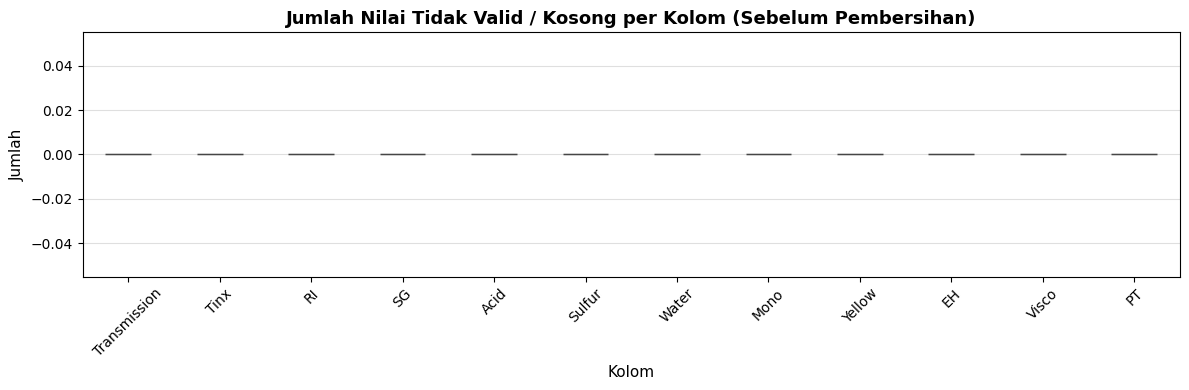


Jumlah nilai tidak valid per kolom:
Transmission    0
Tinx            0
RI              0
SG              0
Acid            0
Sulfur          0
Water           0
Mono            0
Yellow          0
EH              0
Visco           0
PT              0
dtype: int64


In [7]:
# Visualisasi missing value (sebelum pembersihan)
missing_before = pd.to_numeric(df_raw[PARAM_COLS].apply(
    lambda col: col.apply(lambda x: pd.isna(x) or str(x).strip() in ['-', ''])
).sum(), errors='coerce')

fig, ax = plt.subplots(figsize=(12, 4))
missing_before.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='black')
ax.set_title('Jumlah Nilai Tidak Valid / Kosong per Kolom (Sebelum Pembersihan)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Kolom', fontsize=11)
ax.set_ylabel('Jumlah', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('missing_sebelum_pembersihan.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nJumlah nilai tidak valid per kolom:")
print(missing_before)

## 3. PEMBERSIHAN DATA

In [8]:
df = df_raw.copy()

# Ganti tanda '-' dan string kosong dengan NaN di kolom numerik
for col in PARAM_COLS:
    df[col] = df[col].apply(lambda x: np.nan if str(x).strip() in ['-', '', 'nan'] else x)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Cek missing value setelah konversi
missing_after_clean = df[PARAM_COLS].isnull().sum()
print("Missing values setelah pembersihan:")
print(missing_after_clean)
print(f"\nTotal missing: {missing_after_clean.sum()}")

Missing values setelah pembersihan:
Transmission    0
Tinx            0
RI              0
SG              0
Acid            0
Sulfur          0
Water           0
Mono            0
Yellow          0
EH              0
Visco           0
PT              0
dtype: int64

Total missing: 0


## 4. ENCODING FITUR KATEGORIKAL

Kolom **APE** (Appearance) di-encode:
- Nilai yang mengandung kata *clear* (tidak peduli huruf besar/kecil) → **1**
- Nilai lainnya (Bergaram, Cloudy, GARAM, dll.) → **0**

In [9]:
print("Nilai unik APE sebelum encoding:")
print(df[CAT_COL].value_counts())
print()

# Encode: 'clear' (case-insensitive) → 1, lainnya → 0
df['APE_encoded'] = df[CAT_COL].apply(
    lambda x: 1 if str(x).strip().lower() == 'clear' else 0
)

print("Distribusi APE setelah encoding:")
print(df['APE_encoded'].value_counts().rename({1: 'Clear (1)', 0: 'Not Clear (0)'}))
print()
print(f"Total Clear (1)     : {(df['APE_encoded'] == 1).sum()}")
print(f"Total Not Clear (0) : {(df['APE_encoded'] == 0).sum()}")

Nilai unik APE sebelum encoding:
APE
Clear       1256
clear        169
CLEAR         66
Bergaram       2
Cloudy         2
GARAM          1
cLEAR          1
5              1
yelow          1
Name: count, dtype: int64

Distribusi APE setelah encoding:
APE_encoded
Clear (1)        1492
Not Clear (0)       7
Name: count, dtype: int64

Total Clear (1)     : 1492
Total Not Clear (0) : 7


## 5. KNN IMPUTATION

Mengisi nilai yang masih kosong (NaN) pada kolom numerik menggunakan **KNNImputer** dengan `n_neighbors=5`.

In [10]:
# Semua fitur yang digunakan: numerik + APE encoded
FEATURE_COLS = PARAM_COLS + ['APE_encoded']

print(f"Fitur yang digunakan ({len(FEATURE_COLS)} fitur):")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col}")

print(f"\nMissing sebelum imputation:")
print(df[FEATURE_COLS].isnull().sum())

# KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df[FEATURE_COLS] = imputer.fit_transform(df[FEATURE_COLS])

# Pastikan APE_encoded tetap 0 atau 1 setelah imputation
df['APE_encoded'] = df['APE_encoded'].round().astype(int).clip(0, 1)

print(f"\nMissing setelah KNN Imputation:")
print(df[FEATURE_COLS].isnull().sum())
print("\nKNN Imputation selesai!")

Fitur yang digunakan (13 fitur):
   1. Transmission
   2. Tinx
   3. RI
   4. SG
   5. Acid
   6. Sulfur
   7. Water
   8. Mono
   9. Yellow
  10. EH
  11. Visco
  12. PT
  13. APE_encoded

Missing sebelum imputation:
Transmission    0
Tinx            0
RI              0
SG              0
Acid            0
Sulfur          0
Water           0
Mono            0
Yellow          0
EH              0
Visco           0
PT              0
APE_encoded     0
dtype: int64

Missing setelah KNN Imputation:
Transmission    0
Tinx            0
RI              0
SG              0
Acid            0
Sulfur          0
Water           0
Mono            0
Yellow          0
EH              0
Visco           0
PT              0
APE_encoded     0
dtype: int64

KNN Imputation selesai!


In [11]:
# Statistik deskriptif setelah imputation
print("Statistik Deskriptif setelah Imputation:")
df[FEATURE_COLS].describe().round(4)

Statistik Deskriptif setelah Imputation:


,Transmission,Tinx,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT,APE_encoded
count,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000,1499.0000
mean,99.7589,19.0954,1.5082,1.1723,0.2395,11.9604,3.5015,22.0113,7.8327,0.0002,53.6892,7.0469,0.9953
std,23.0893,0.1949,0.0013,0.0105,0.3904,0.5597,0.2180,4.0080,0.2499,0.0004,2.5082,2.6888,0.0682
min,91.0840,15.3370,1.4838,1.0750,0.0192,0.2020,0.2030,0.0000,3.4900,0.0000,41.0000,2.0000,0.0000
25%,99.1160,19.0725,1.5079,1.1698,0.2002,11.9676,3.4800,21.4670,7.7000,0.0001,52.3660,5.0000,1.0000
50%,99.2022,19.0990,1.5083,1.1721,0.2030,12.0000,3.4800,21.9960,7.8000,0.0001,53.7400,5.0000,1.0000
75%,99.2610,19.1267,1.5086,1.1748,0.2101,12.0362,3.4860,22.5180,7.9150,0.0002,55.1300,10.0000,1.0000
max,993.0000,20.3126,1.5108,1.5087,11.9960,19.7000,7.9200,95.4900,12.0270,0.0098,73.5000,30.0000,1.0000


## 6. LABELING BERDASARKAN BATCH

### Spesifikasi Standar Kualitas Produk TIN STABILIZER MT-620:

| Parameter | Spesifikasi |
|-----------|-------------|
| Transmission | > 98 |
| Appearance (APE) | Clear |
| Tin Content (Tinx) | 18.8 – 19.2 |
| Refractive Index (RI) | 1.507 – 1.511 |
| Specific Gravity (SG) | 1.160 – 1.180 |
| Acid Value | ≤ 3.0 |
| Sulfur | 11.5 – 12.5 |
| Water Content | < 3.5 |
| Monomethyltin (Mono) | 19.5 – 28.5 |
| Yellowish Index (Yellow) | < 9.0 |
| 2-EH (EH) | < 0.7 |
| Viscosity (Visco) | 40 – 80 |
| Pt-Co (PT) | ≤ 30 |

**Aturan Labeling:**
- Cek setiap **baris** (pengukuran): apakah semua parameter memenuhi spesifikasi → **Passed** atau **Not Passed**
- Cek per **batch**: jika semua baris dalam 1 batch *Passed* → **Layak (1)**, jika ada ≥ 1 baris *Not Passed* → **Tidak Layak (0)**

In [ ]:
# Definisi threshold spesifikasi produk
THRESHOLDS = {
    'Transmission' : ('gt',  98.0),          # Transmission > 98
    'APE_encoded'  : ('eq',  1),             # APE harus Clear
    'Tinx'         : ('range', 18.8, 19.2),  # 18.8 - 19.2
    'RI'           : ('range', 1.507, 1.511),
    'SG'           : ('range', 1.160, 1.180),
    'Acid'         : ('lte',  3.0),          # <= 3.0
    'Sulfur'       : ('range', 11.5, 12.5),
    'Water'        : ('lt',   3.5),          # < 3.5
    'Mono'         : ('range', 19.5, 28.5),
    'Yellow'       : ('lt',   9.0),
    'EH'           : ('lt',   0.7),
    'Visco'        : ('range', 40.0, 80.0),
    'PT'           : ('lte',  30.0),
}

def check_row_passed(row):
    """
    Mengecek satu baris data.
    Return 'Passed' jika SEMUA parameter memenuhi spesifikasi,
    Return 'Not Passed' jika ada satu saja yang gagal.
    """
    for param, spec in THRESHOLDS.items():
        val = row[param]
        if pd.isna(val):
            return 'Not Passed'
        kind = spec[0]
        if kind == 'gt':
            if not (val > spec[1]):
                return 'Not Passed'
        elif kind == 'gte':
            if not (val >= spec[1]):
                return 'Not Passed'
        elif kind == 'lt':
            if not (val < spec[1]):
                return 'Not Passed'
        elif kind == 'lte':
            if not (val <= spec[1]):
                return 'Not Passed'
        elif kind == 'eq':
            if val != spec[1]:
                return 'Not Passed'
        elif kind == 'range':
            if not (spec[1] <= val <= spec[2]):
                return 'Not Passed'
    return 'Passed'

# Langkah 1: cek per baris
df['Row_Status'] = df.apply(check_row_passed, axis=1)

print("=" * 60)
print("HASIL PENGECEKAN PER BARIS")
print("=" * 60)
print(df['Row_Status'].value_counts())
print(f"\nPersentase Passed  : {(df['Row_Status'] == 'Passed').mean()*100:.2f}%")
print(f"Persentase Not Passed: {(df['Row_Status'] == 'Not Passed').mean()*100:.2f}%")

HASIL PENGECEKAN PER BARIS
Row_Status
Passed        1271
Not Passed     228
Name: count, dtype: int64

Persentase Passed  : 84.79%
Persentase Not Passed: 15.21%


In [ ]:
# Analisis parameter yang paling banyak menyebabkan Not Passed
print("=" * 70)
print("ANALISIS PARAMETER PENYEBAB NOT PASSED")
print("=" * 70)

fail_count = {}
for param, spec in THRESHOLDS.items():
    kind = spec[0]
    if kind == 'gt':
        n_fail = (df[param] <= spec[1]).sum()
    elif kind == 'gte':
        n_fail = (df[param] < spec[1]).sum()
    elif kind == 'lt':
        n_fail = (df[param] >= spec[1]).sum()
    elif kind == 'lte':
        n_fail = (df[param] > spec[1]).sum()
    elif kind == 'eq':
        n_fail = (df[param] != spec[1]).sum()
    elif kind == 'range':
        n_fail = ((df[param] < spec[1]) | (df[param] > spec[2])).sum()
    fail_count[param] = n_fail
    
fail_series = pd.Series(fail_count).sort_values(ascending=False)
for param, n in fail_series.items():
    spec = THRESHOLDS[param]
    if spec[0] == 'range':
        spec_str = f"[{spec[1]}, {spec[2]}]"
    elif spec[0] == 'gt':
        spec_str = f"> {spec[1]}"
    elif spec[0] == 'lt':
        spec_str = f"< {spec[1]}"
    elif spec[0] == 'lte':
        spec_str = f"<= {spec[1]}"
    elif spec[0] == 'eq':
        spec_str = f"== {spec[1]}"
    else:
        spec_str = str(spec[1:])
    pct = n / len(df) * 100
    print(f"  {param:15s} (Spec: {spec_str:15s}): {n:4d} baris gagal ({pct:.2f}%)")

ANALISIS PARAMETER PENYEBAB NOT PASSED
  Tinx            (Spec: [18.8, 19.2]   ):   85 baris gagal (5.67%)
  Mono            (Spec: [19.5, 28.5]   ):   73 baris gagal (4.87%)
  Water           (Spec: < 3.5          ):   50 baris gagal (3.34%)
  Sulfur          (Spec: [11.5, 12.5]   ):   47 baris gagal (3.14%)
  SG              (Spec: [1.16, 1.18]   ):   46 baris gagal (3.07%)
  RI              (Spec: [1.507, 1.511] ):   39 baris gagal (2.60%)
  Transmission    (Spec: > 98.0         ):   11 baris gagal (0.73%)
  APE_encoded     (Spec: == 1           ):    7 baris gagal (0.47%)
  Yellow          (Spec: < 9.0          ):    4 baris gagal (0.27%)
  Acid            (Spec: <= 3.0         ):    2 baris gagal (0.13%)
  EH              (Spec: < 0.7          ):    0 baris gagal (0.00%)
  Visco           (Spec: [40.0, 80.0]   ):    0 baris gagal (0.00%)
  PT              (Spec: <= 30.0        ):    0 baris gagal (0.00%)


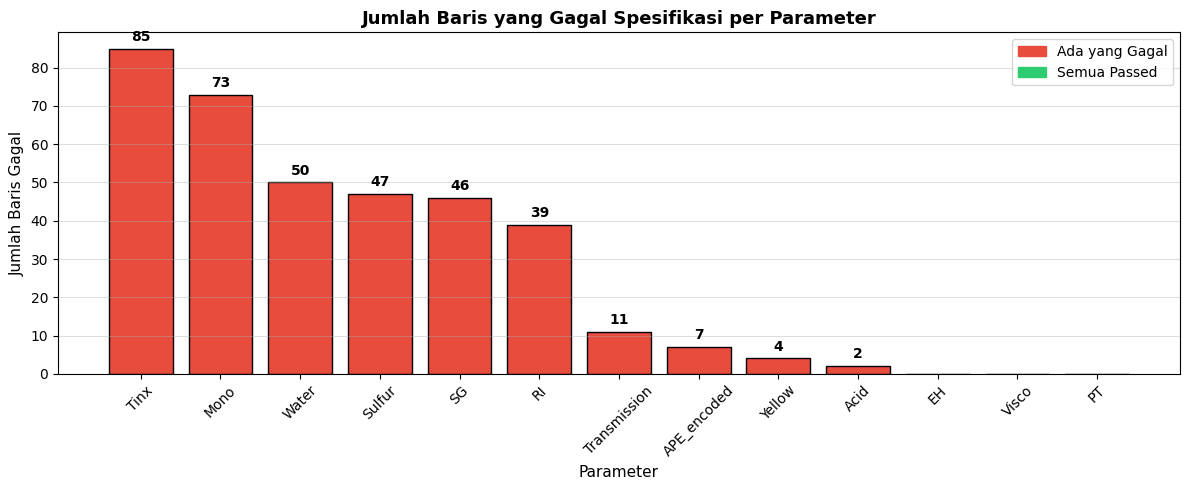

Grafik disimpan: parameter_gagal.png


In [14]:
# Visualisasi jumlah baris gagal per parameter
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in fail_series.values]
bars = ax.bar(fail_series.index, fail_series.values, color=colors, edgecolor='black')
for bar, val in zip(bars, fail_series.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Jumlah Baris yang Gagal Spesifikasi per Parameter', fontsize=13, fontweight='bold')
ax.set_xlabel('Parameter', fontsize=11)
ax.set_ylabel('Jumlah Baris Gagal', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.4)
red_patch   = mpatches.Patch(color='#e74c3c', label='Ada yang Gagal')
green_patch = mpatches.Patch(color='#2ecc71', label='Semua Passed')
ax.legend(handles=[red_patch, green_patch], fontsize=10)
plt.tight_layout()
plt.savefig('parameter_gagal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: parameter_gagal.png")

In [15]:
# Langkah 2: labeling per batch
# Batch dinyatakan TIDAK LAYAK jika ada SATU saja baris 'Not Passed'
batch_label = (
    df.groupby('Batch')['Row_Status']
    .apply(lambda s: 1 if (s == 'Passed').all() else 0)
    .rename('Label_Batch')
)

# Map label batch ke setiap baris
df = df.merge(batch_label, on='Batch', how='left')

print("=" * 60)
print("HASIL LABELING PER BATCH")
print("=" * 60)
print(f"Total batch    : {df['Batch'].nunique()}")
print(f"Batch Layak    : {batch_label.sum()}  ({batch_label.mean()*100:.2f}%)")
print(f"Batch Tdk Layak: {(batch_label == 0).sum()}  ({(batch_label == 0).mean()*100:.2f}%)")
print()
print("Distribusi Label pada baris data:")
print(df['Label_Batch'].value_counts().rename({1: 'Layak (1)', 0: 'Tidak Layak (0)'}))

HASIL LABELING PER BATCH
Total batch    : 819
Batch Layak    : 605  (73.87%)
Batch Tdk Layak: 214  (26.13%)

Distribusi Label pada baris data:
Label_Batch
Layak (1)          1119
Tidak Layak (0)     380
Name: count, dtype: int64


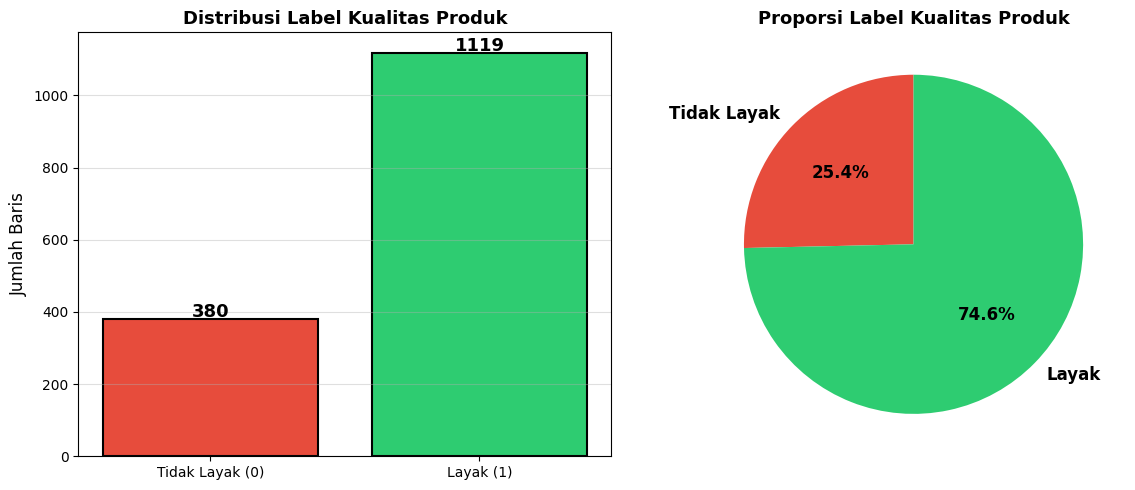

Grafik disimpan: distribusi_label.png


In [16]:
# Visualisasi distribusi label
label_counts = df['Label_Batch'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
clrs = ['#e74c3c', '#2ecc71']
lbls = ['Tidak Layak (0)', 'Layak (1)']
bars = axes[0].bar(lbls, label_counts.values, color=clrs, edgecolor='black', linewidth=1.5)
for bar, v in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(v), ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Baris', fontsize=12)
axes[0].set_title('Distribusi Label Kualitas Produk', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.4)

# Pie chart
axes[1].pie(label_counts.values,
            labels=['Tidak Layak', 'Layak'],
            autopct='%1.1f%%',
            colors=clrs,
            startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporsi Label Kualitas Produk', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: distribusi_label.png")

In [17]:
# Simpan data berlabel untuk referensi
df_labeled = df[['ID', 'Batch', 'Tanggal'] + FEATURE_COLS + ['Row_Status', 'Label_Batch']].copy()
df_labeled.to_excel('Data_MT620_Labeled_Hasil.xlsx', index=False)
print("Data berlabel disimpan: Data_MT620_Labeled_Hasil.xlsx")
df_labeled.head(10)

Data berlabel disimpan: Data_Labeled_Hasil.xlsx


,ID,Batch,Tanggal,Transmission,Tinx,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT,APE_encoded,Row_Status,Label_Batch
0,11,TG2024L28,2025-05-07,99.275,19.07866,1.508670,1.17230,0.2030,12.0810,3.480,22.384,7.84,0.00010,47.20,10.0,1,Passed,1
1,12,TG2025A07,2025-05-07,99.229,19.13802,1.508820,1.17380,0.2540,11.9260,3.480,22.034,7.90,0.00050,45.07,10.0,1,Passed,1
2,13,TG2025B07-1,2025-05-07,99.286,19.11352,1.509300,1.17405,0.2010,11.8490,3.480,21.766,7.79,0.00010,49.40,10.0,1,Passed,1
3,38,TG02025E05,2025-05-09,99.216,19.12550,1.508490,1.16940,0.2540,12.0990,3.490,21.552,7.85,0.00014,49.60,10.0,1,Passed,1
4,39,TG02025E06,2025-05-09,99.308,19.08874,1.508820,1.17240,0.2500,12.1760,3.490,22.250,7.82,0.00012,47.20,10.0,1,Passed,1
5,81,TG2025E063,2025-05-16,99.201,19.09730,1.509520,1.17925,0.2028,11.9870,3.484,22.096,7.64,0.00012,52.94,6.0,1,Passed,1
6,90,TG2025E062,2025-05-17,99.178,19.08138,1.504850,1.17472,0.2010,12.0890,3.484,22.204,7.60,0.00018,53.64,10.0,1,Not Passed,0
7,92,TG2025E062,2025-05-17,99.215,19.07106,1.509032,1.17162,0.2200,12.0166,3.480,22.600,7.79,0.00016,54.08,10.0,1,Passed,0
8,93,TG2025E063,2025-05-17,99.220,19.08856,1.507970,1.17575,0.2062,11.9870,3.480,22.266,7.73,0.00014,55.70,10.0,1,Passed,1
9,95,TG2025E064,2025-05-17,99.171,19.11540,1.509930,1.18156,0.2000,12.0090,3.482,21.740,7.84,0.00010,51.66,6.0,1,Not Passed,0


## 7. SPLIT DATA — 80% Training, 20% Validasi

In [18]:
X = df[FEATURE_COLS].copy()
y = df['Label_Batch'].copy()

print(f"Fitur (X) : {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nDistribusi y: {y.value_counts().to_dict()}")

# Cek apakah kedua kelas ada
assert y.nunique() >= 2, (
    "PERINGATAN: Data hanya memiliki 1 kelas! "
    "Periksa kembali threshold spesifikasi."
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("SPLIT DATA BERHASIL!")
print("=" * 60)
print(f"Data Training  : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Distribusi   : {y_train.value_counts().to_dict()}")
print(f"Data Validasi  : {X_val.shape[0]} baris ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Distribusi   : {y_val.value_counts().to_dict()}")
print("=" * 60)

Fitur (X) : (1499, 13)
Target (y): (1499,)

Distribusi y: {1: 1119, 0: 380}

SPLIT DATA BERHASIL!
Data Training  : 1199 baris (80.0%)
  Distribusi   : {1: 895, 0: 304}
Data Validasi  : 300 baris (20.0%)
  Distribusi   : {1: 224, 0: 76}


## 8. K-FOLD CROSS VALIDATION (5-Fold Stratified)

Cross validation dilakukan **hanya pada data training** untuk mendapatkan estimasi performa yang lebih stabil dan menghindari overfitting.

In [19]:
K_FOLDS = 5
cv_strategy = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

print(f"Setup K-Fold Cross Validation:")
print(f"  Jumlah Fold    : {K_FOLDS}")
print(f"  Strategi       : Stratified (proporsi kelas dijaga)")
print(f"  Data digunakan : Data Training ({len(X_train)} baris)")

Setup K-Fold Cross Validation:
  Jumlah Fold    : 5
  Strategi       : Stratified (proporsi kelas dijaga)
  Data digunakan : Data Training (1199 baris)


In [20]:
# Inisialisasi model XGBoost
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=3,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

print("Model XGBoost berhasil diinisialisasi!")
print(f"\nHyperparameters:")
print(f"  n_estimators      : {model.n_estimators}")
print(f"  max_depth         : {model.max_depth}")
print(f"  learning_rate     : {model.learning_rate}")
print(f"  subsample         : {model.subsample}")
print(f"  colsample_bytree  : {model.colsample_bytree}")
print(f"  gamma             : {model.gamma}")
print(f"  min_child_weight  : {model.min_child_weight}")

Model XGBoost berhasil diinisialisasi!

Hyperparameters:
  n_estimators      : 200
  max_depth         : 5
  learning_rate     : 0.05
  subsample         : 0.8
  colsample_bytree  : 0.8
  gamma             : 1
  min_child_weight  : 3


In [21]:
print("=" * 65)
print(f"MELAKUKAN {K_FOLDS}-FOLD CROSS VALIDATION...")
print("=" * 65)

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
cv_scores = {}

for metric in scoring_metrics:
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv_strategy, scoring=metric)
    cv_scores[metric] = scores
    print(f"\n{metric.upper():10s}:")
    for i, s in enumerate(scores, 1):
        print(f"  Fold {i}: {s:.4f}")
    print(f"  Mean  : {scores.mean():.4f}  |  Std: {scores.std():.4f}")

print("\n" + "=" * 65)
print("CROSS VALIDATION SELESAI!")
print("=" * 65)

MELAKUKAN 5-FOLD CROSS VALIDATION...

ACCURACY  :
  Fold 1: 0.9042
  Fold 2: 0.8792
  Fold 3: 0.8583
  Fold 4: 0.8667
  Fold 5: 0.8703
  Mean  : 0.8757  |  Std: 0.0157

PRECISION :
  Fold 1: 0.8939
  Fold 2: 0.8606
  Fold 3: 0.8571
  Fold 4: 0.8693
  Fold 5: 0.8663
  Mean  : 0.8695  |  Std: 0.0130

RECALL    :
  Fold 1: 0.9888
  Fold 2: 1.0000
  Fold 3: 0.9721
  Fold 4: 0.9665
  Fold 5: 0.9777
  Mean  : 0.9810  |  Std: 0.0120

F1        :
  Fold 1: 0.9390
  Fold 2: 0.9251
  Fold 3: 0.9110
  Fold 4: 0.9153
  Fold 5: 0.9186
  Mean  : 0.9218  |  Std: 0.0097

CROSS VALIDATION SELESAI!


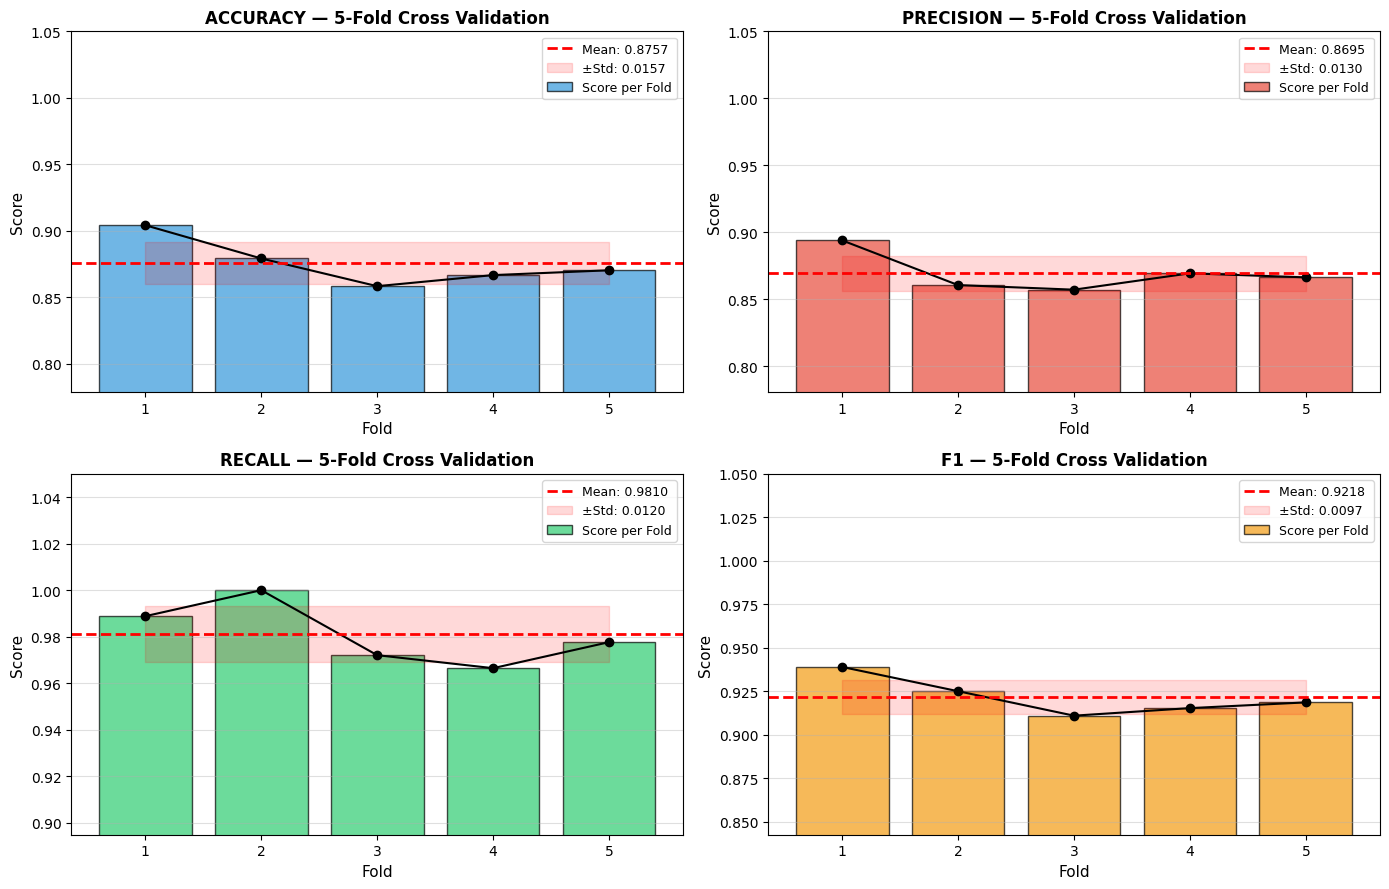

Grafik disimpan: cross_validation_results.png


In [22]:
# Visualisasi hasil Cross Validation
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()
metric_colors = {'accuracy': '#3498db', 'precision': '#e74c3c',
                 'recall': '#2ecc71', 'f1': '#f39c12'}

for idx, (metric, scores) in enumerate(cv_scores.items()):
    ax = axes[idx]
    folds = range(1, K_FOLDS + 1)
    color = metric_colors[metric]

    ax.bar(folds, scores, color=color, alpha=0.7, edgecolor='black', label='Score per Fold')
    ax.plot(folds, scores, marker='o', color='black', linewidth=1.5, markersize=6)

    mean_score = scores.mean()
    std_score  = scores.std()
    ax.axhline(mean_score, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_score:.4f}')
    ax.fill_between(folds, mean_score - std_score, mean_score + std_score,
                    alpha=0.15, color='red', label=f'±Std: {std_score:.4f}')

    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{metric.upper()} — {K_FOLDS}-Fold Cross Validation',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xticks(list(folds))
    ax.set_ylim([max(0, mean_score - 3*std_score - 0.05), 1.05])
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: cross_validation_results.png")

## 9. TRAINING MODEL XGBOOST

In [23]:
print("Melatih model pada seluruh data training...")
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print("Training selesai!")

Melatih model pada seluruh data training...
Training selesai!


## 10. PREDIKSI & METRIK EVALUASI

In [24]:
# Prediksi
y_train_pred  = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1]
y_val_pred    = model.predict(X_val)
y_val_proba   = model.predict_proba(X_val)[:, 1]

def hitung_metrik(y_true, y_pred, nama):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{'='*55}")
    print(f"METRIK EVALUASI — {nama}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"{'='*55}")
    return acc, prec, rec, f1

train_acc, train_prec, train_rec, train_f1 = hitung_metrik(y_train, y_train_pred, "DATA TRAINING")
val_acc,   val_prec,   val_rec,   val_f1   = hitung_metrik(y_val,   y_val_pred,   "DATA VALIDASI")


METRIK EVALUASI — DATA TRAINING
  Accuracy  : 0.9216  (92.16%)
  Precision : 0.9074
  Recall    : 0.9966
  F1-Score  : 0.9499

METRIK EVALUASI — DATA VALIDASI
  Accuracy  : 0.8367  (83.67%)
  Precision : 0.8431
  Recall    : 0.9598
  F1-Score  : 0.8977


In [25]:
print("\nCLASSIFICATION REPORT — DATA VALIDASI")
print("=" * 65)
print(classification_report(y_val, y_val_pred,
                             target_names=['Tidak Layak (0)', 'Layak (1)']))


CLASSIFICATION REPORT — DATA VALIDASI
                 precision    recall  f1-score   support

Tidak Layak (0)       0.80      0.47      0.60        76
      Layak (1)       0.84      0.96      0.90       224

       accuracy                           0.84       300
      macro avg       0.82      0.72      0.75       300
   weighted avg       0.83      0.84      0.82       300



## 11. CONFUSION MATRIX

In [26]:
cm_train = confusion_matrix(y_train, y_train_pred)
cm_val   = confusion_matrix(y_val,   y_val_pred)

def print_cm(cm, nama):
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion Matrix — {nama}:")
    print(f"  True Negatives  (TN): {tn}  — Tidak Layak diprediksi Tidak Layak")
    print(f"  False Positives (FP): {fp}  — Tidak Layak diprediksi Layak (BAHAYA!)")
    print(f"  False Negatives (FN): {fn}  — Layak diprediksi Tidak Layak (pemborosan)")
    print(f"  True Positives  (TP): {tp}  — Layak diprediksi Layak")

print_cm(cm_train, "TRAINING")
print_cm(cm_val,   "VALIDASI")


Confusion Matrix — TRAINING:
  True Negatives  (TN): 213  — Tidak Layak diprediksi Tidak Layak
  False Positives (FP): 91  — Tidak Layak diprediksi Layak (BAHAYA!)
  False Negatives (FN): 3  — Layak diprediksi Tidak Layak (pemborosan)
  True Positives  (TP): 892  — Layak diprediksi Layak

Confusion Matrix — VALIDASI:
  True Negatives  (TN): 36  — Tidak Layak diprediksi Tidak Layak
  False Positives (FP): 40  — Tidak Layak diprediksi Layak (BAHAYA!)
  False Negatives (FN): 9  — Layak diprediksi Tidak Layak (pemborosan)
  True Positives  (TP): 215  — Layak diprediksi Layak


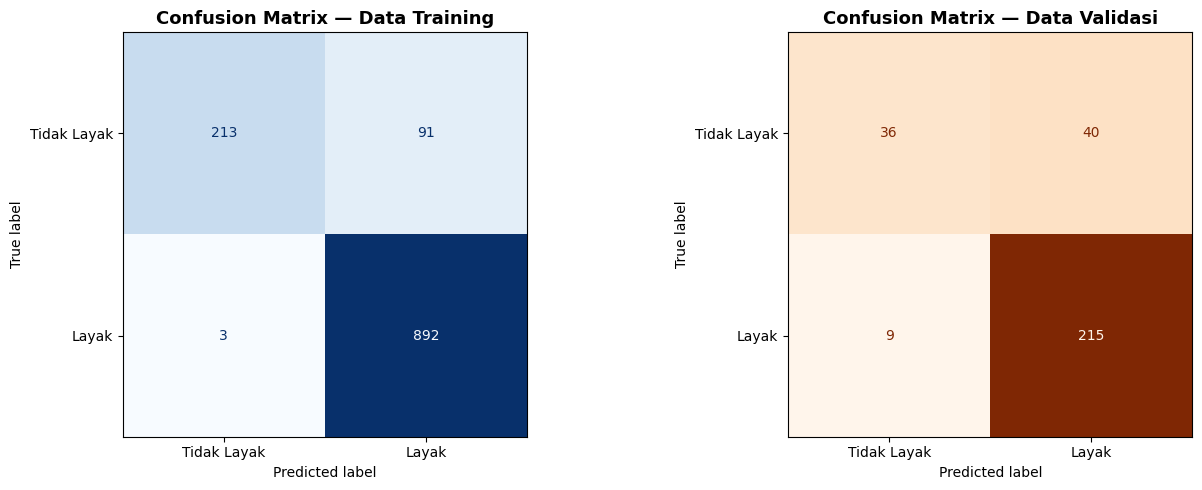

Grafik disimpan: confusion_matrices.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm_train, display_labels=['Tidak Layak', 'Layak']).plot(
    ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Confusion Matrix — Data Training', fontsize=13, fontweight='bold')
axes[0].grid(False)

ConfusionMatrixDisplay(cm_val, display_labels=['Tidak Layak', 'Layak']).plot(
    ax=axes[1], cmap='Oranges', values_format='d', colorbar=False)
axes[1].set_title('Confusion Matrix — Data Validasi', fontsize=13, fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: confusion_matrices.png")

## 12. FEATURE IMPORTANCE

In [28]:
feat_imp = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance' : model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=" * 50)
print("FEATURE IMPORTANCE (XGBoost)")
print("=" * 50)
print(feat_imp.to_string(index=False))
print("=" * 50)

FEATURE IMPORTANCE (XGBoost)
     Feature  Importance
       Water    0.194560
        Tinx    0.145482
        Mono    0.118180
          SG    0.092127
          RI    0.080300
      Sulfur    0.071404
        Acid    0.054963
          EH    0.052836
       Visco    0.050764
Transmission    0.048805
      Yellow    0.046184
          PT    0.044395
 APE_encoded    0.000000


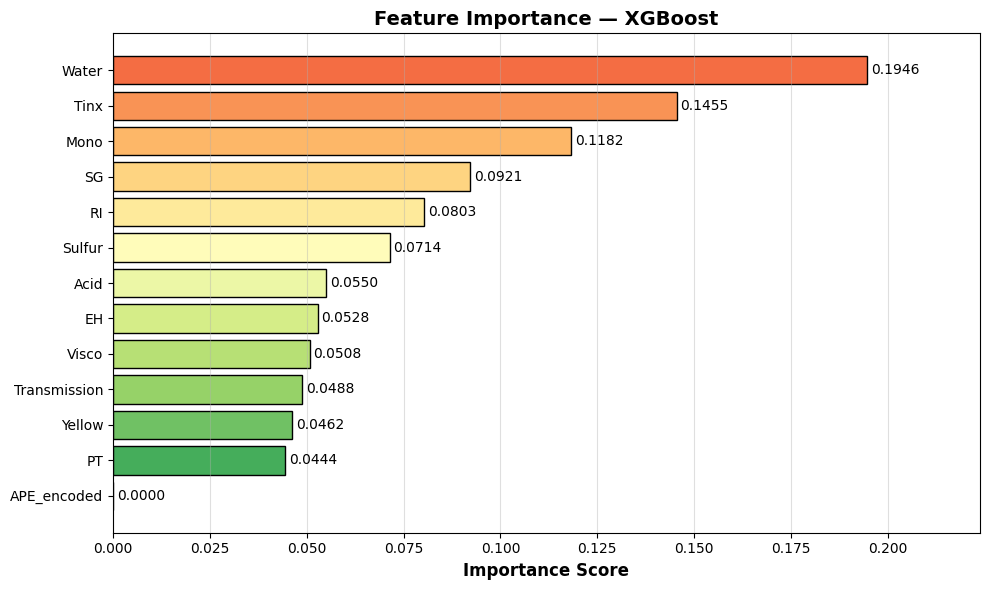

Grafik disimpan: feature_importance.png


In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))

bars = ax.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1],
               color=palette[::-1], edgecolor='black')
for bar, val in zip(bars, feat_imp['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance — XGBoost', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
ax.set_xlim([0, feat_imp['Importance'].max() * 1.15])
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: feature_importance.png")

## 13. PERBANDINGAN METRIK & VISUALISASI AKHIR

In [30]:
comparison_df = pd.DataFrame({
    'Metrik'   : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training' : [train_acc,  train_prec,  train_rec,  train_f1],
    'Validasi' : [val_acc,    val_prec,    val_rec,    val_f1],
    'CV Mean'  : [cv_scores['accuracy'].mean(),  cv_scores['precision'].mean(),
                  cv_scores['recall'].mean(),     cv_scores['f1'].mean()],
    'CV Std'   : [cv_scores['accuracy'].std(),   cv_scores['precision'].std(),
                  cv_scores['recall'].std(),      cv_scores['f1'].std()],
})

print("=" * 80)
print("TABEL PERBANDINGAN METRIK EVALUASI")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

TABEL PERBANDINGAN METRIK EVALUASI
   Metrik  Training  Validasi  CV Mean   CV Std
 Accuracy  0.921601  0.836667 0.875725 0.015715
Precision  0.907426  0.843137 0.869469 0.012959
   Recall  0.996648  0.959821 0.981006 0.012034
 F1-Score  0.949947  0.897704 0.921806 0.009743


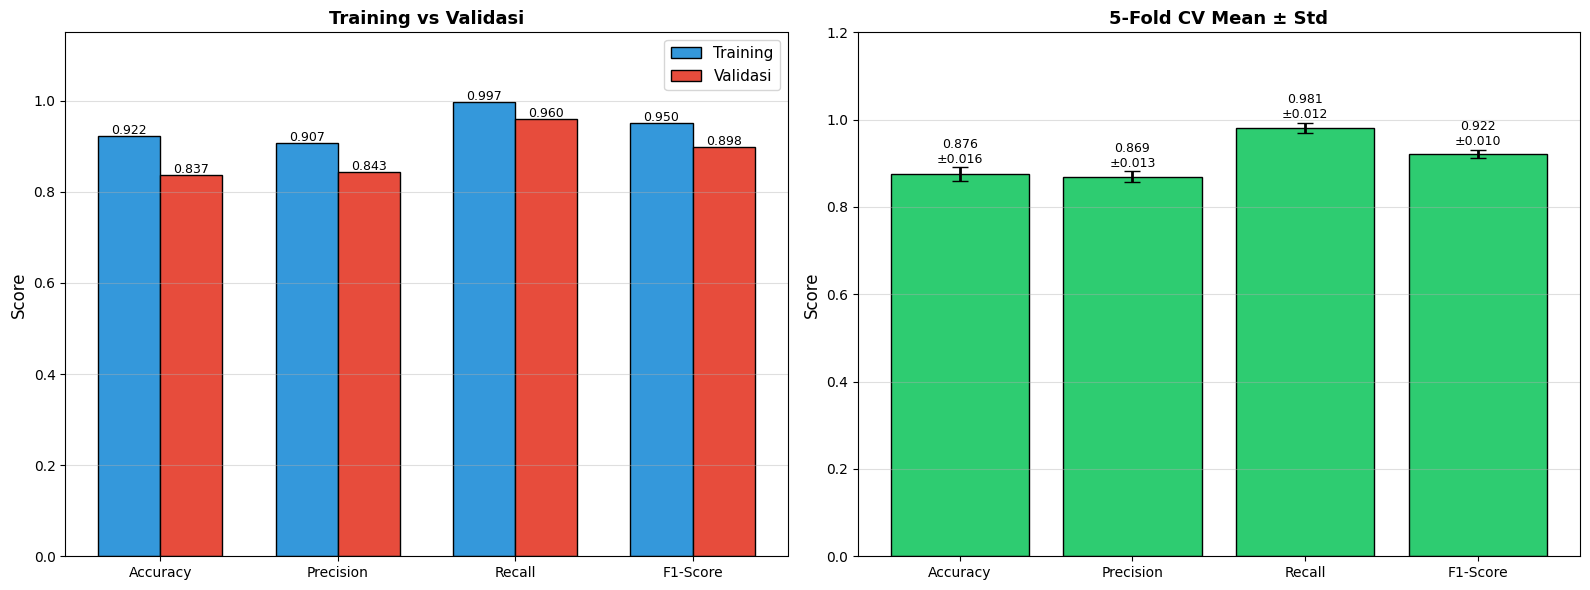

Grafik disimpan: metrics_comparison.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
w = 0.35

# Plot 1: Training vs Validasi
b1 = axes[0].bar(x - w/2, comparison_df['Training'], w,
                  label='Training', color='#3498db', edgecolor='black')
b2 = axes[0].bar(x + w/2, comparison_df['Validasi'],  w,
                  label='Validasi',  color='#e74c3c', edgecolor='black')

for bar in b1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in b2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Metrik'])
axes[0].set_ylim([0, 1.15])
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Training vs Validasi', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.4)

# Plot 2: Cross-Validation mean ± std
b3 = axes[1].bar(x, comparison_df['CV Mean'],
                  yerr=comparison_df['CV Std'],
                  color='#2ecc71', edgecolor='black', capsize=6,
                  error_kw={'linewidth': 2})
for i, (m, s) in enumerate(zip(comparison_df['CV Mean'], comparison_df['CV Std'])):
    axes[1].text(i, m + s + 0.01, f'{m:.3f}\n±{s:.3f}',
                 ha='center', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Metrik'])
axes[1].set_ylim([0, 1.2])
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title(f'{K_FOLDS}-Fold CV Mean ± Std', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: metrics_comparison.png")

## 14. SIMPAN MODEL

In [32]:
import pickle

MODEL_FILE = 'xgboost_mt620_model.pkl'
with open(MODEL_FILE, 'wb') as f:
    pickle.dump(model, f)

print(f"Model disimpan: {MODEL_FILE}")

Model disimpan: xgboost_tinstab_model.pkl


## 15. RINGKASAN AKHIR

In [33]:
print("\n" + "="*80)
print("RINGKASAN HASIL PENELITIAN — KLASIFIKASI TIN STABILIZER MT-620")
print("="*80)

print(f"\n1. DATA:")
print(f"   Sumber File      : Data_Chemical_MT620_Only_Final.xlsx")
print(f"   Total Baris      : {len(df)}")
print(f"   Total Batch      : {df['Batch'].nunique()}")
print(f"   Batch Layak      : {batch_label.sum()} ({batch_label.mean()*100:.1f}%)")
print(f"   Batch Tdk Layak  : {(batch_label==0).sum()} ({(1-batch_label.mean())*100:.1f}%)")
print(f"   Data Training    : {len(X_train)} baris (80%)")
print(f"   Data Validasi    : {len(X_val)} baris (20%)")
print(f"   Jumlah Fitur     : {len(FEATURE_COLS)}")

print(f"\n2. MODEL:")
print(f"   Algoritma        : XGBoost Classifier")
print(f"   n_estimators     : {model.n_estimators}")
print(f"   max_depth        : {model.max_depth}")
print(f"   learning_rate    : {model.learning_rate}")
print(f"   subsample        : {model.subsample}")

print(f"\n3. CROSS-VALIDATION ({K_FOLDS}-Fold Stratified):")
for m, scores in cv_scores.items():
    print(f"   {m.capitalize():10s}: {scores.mean():.4f} ± {scores.std():.4f}")

print(f"\n4. PERFORMA TRAINING:")
print(f"   Accuracy    : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   Precision   : {train_prec:.4f}")
print(f"   Recall      : {train_rec:.4f}")
print(f"   F1-Score    : {train_f1:.4f}")

print(f"\n5. PERFORMA VALIDASI:")
print(f"   Accuracy    : {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"   Precision   : {val_prec:.4f}")
print(f"   Recall      : {val_rec:.4f}")
print(f"   F1-Score    : {val_f1:.4f}")

print(f"\n6. TOP 3 FITUR PALING PENTING:")
for _, row_fi in feat_imp.head(3).iterrows():
    print(f"   {row_fi['Feature']:15s}: {row_fi['Importance']:.4f}")

print(f"\n7. FILE OUTPUT:")
output_files = [
    'Data_MT620_Labeled_Hasil.xlsx',
    'xgboost_mt620_model.pkl',
    'missing_sebelum_pembersihan.png',
    'parameter_gagal.png',
    'distribusi_label.png',
    'cross_validation_results.png',
    'confusion_matrices.png',
    'feature_importance.png',
    'metrics_comparison.png',
]
for f_out in output_files:
    print(f"   - {f_out}")

print("\n" + "="*80)
print("ANALISIS SELESAI!")
print("="*80)


RINGKASAN HASIL PENELITIAN — KLASIFIKASI TIN STABILIZER MT-620

1. DATA:
   Sumber File      : Data_Chemical_Imputed.xlsx
   Total Baris      : 1499
   Total Batch      : 819
   Batch Layak      : 605 (73.9%)
   Batch Tdk Layak  : 214 (26.1%)
   Data Training    : 1199 baris (80%)
   Data Validasi    : 300 baris (20%)
   Jumlah Fitur     : 13

2. MODEL:
   Algoritma        : XGBoost Classifier
   n_estimators     : 200
   max_depth        : 5
   learning_rate    : 0.05
   subsample        : 0.8

3. CROSS-VALIDATION (5-Fold Stratified):
   Accuracy  : 0.8757 ± 0.0157
   Precision : 0.8695 ± 0.0130
   Recall    : 0.9810 ± 0.0120
   F1        : 0.9218 ± 0.0097

4. PERFORMA TRAINING:
   Accuracy    : 0.9216 (92.16%)
   Precision   : 0.9074
   Recall      : 0.9966
   F1-Score    : 0.9499

5. PERFORMA VALIDASI:
   Accuracy    : 0.8367 (83.67%)
   Precision   : 0.8431
   Recall      : 0.9598
   F1-Score    : 0.8977

6. TOP 3 FITUR PALING PENTING:
   Water          : 0.1946
   Tinx           

## 16. KESIMPULAN & INTERPRETASI

### Alur yang Diterapkan:

| Tahap | Keterangan |
|-------|------------|
| **Load Data** | `Data_Chemical_MT620_Only_Final.xlsx` (1780 baris, 24 kolom) |
| **Eksplorasi** | Analisis distribusi, nilai unik, statistik deskriptif |
| **Pembersihan** | Konversi tipe data, ganti `'-'` → `NaN` |
| **Encoding APE** | `Clear` (semua variasi huruf) → `1`, lainnya → `0` |
| **KNN Imputation** | Mengisi `NaN` yang tersisa dengan KNN (k=5) |
| **Labeling Per-Baris** | Cek setiap baris terhadap 13 threshold spesifikasi MT-620 |
| **Labeling Per-Batch** | Batch = Layak (1) jika **semua** baris Passed; jika ada ≥1 Not Passed → Tidak Layak (0) |
| **Split Data** | 80% Training / 20% Validasi (stratified) |
| **K-Fold CV** | 5-Fold Stratified Cross Validation pada data training |
| **Training XGBoost** | Klasifikasi biner: Layak vs Tidak Layak |
| **Evaluasi** | Accuracy, Precision, Recall, F1-Score, Confusion Matrix |

### Interpretasi Confusion Matrix:
- **True Positive (TP)**: Produk layak diprediksi layak ✅
- **True Negative (TN)**: Produk tidak layak diprediksi tidak layak ✅
- **False Positive (FP)**: Produk tidak layak diprediksi layak ❌ **(berbahaya — produk cacat lolos)**
- **False Negative (FN)**: Produk layak diprediksi tidak layak ❌ **(pemborosan — produk bagus ditolak)**

### Rekomendasi:
1. Model dapat digunakan sebagai *early warning system* kontrol kualitas
2. Fokus monitoring pada parameter dengan **Feature Importance tertinggi**
3. Lakukan verifikasi manual untuk setiap prediksi *Tidak Layak*
4. Kumpulkan data lebih banyak untuk meningkatkan akurasi model

---
**Notebook ini siap digunakan untuk laporan penelitian PRA TA.**